This shows the distibution of FiLM parameters(initialzed with identity) , features before and after applying filM when the initial image is passed throught the image backbone EfficientNet followed by 4 FiLMed Resblock each consist of FiLM 

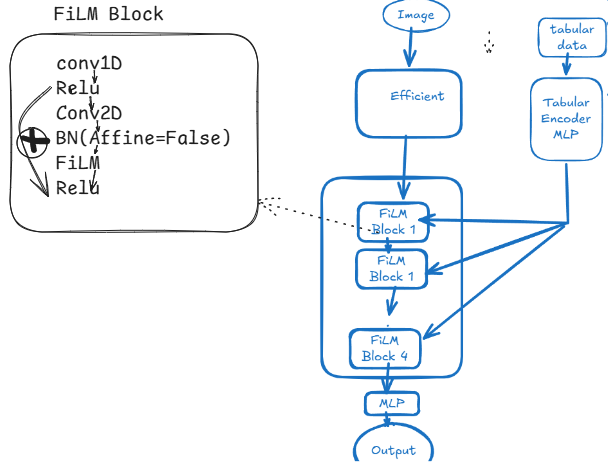

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../../.."))

In [3]:
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gc.enable()
import torch

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../../../.."
data_csv    = os.path.join(main_folder, "data", "train.csv")
img_folder  = os.path.join(main_folder, "data", "train")

# EXPERIMENT-SPECIFIC
cfg_key  = "exp12_film"  # or other key
exp_name = "exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init"
out_dir  = os.path.join(main_folder, "outputs", "extra", exp_name)

df  = pd.read_csv(data_csv)
TARGET   = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

cfg = EXP_CONFIGS[cfg_key].copy()
cfg["name"] = exp_name

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Experiment:", cfg["name"])
print("Out dir:", out_dir)

Device: cuda
Experiment: exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
Out dir: ../../../../outputs/extra/exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init


In [4]:
oof_path = os.path.join(out_dir, "oof_detail.csv")
df_oof   = pd.read_csv(oof_path)

fold_rmse_list = []
for f in range(1, cfg["n_splits"] + 1):
    sub  = df_oof[df_oof.fold == f]
    rmse = ((sub.ytrue - sub.oof_pred) ** 2).mean() ** 0.5
    fold_rmse_list.append((f, rmse))
    print(f"Fold {f} OOF RMSE: {rmse:.4f} (n={len(sub)})")

best_fold, best_rmse = min(fold_rmse_list, key=lambda x: x[1])
print(f"\nBest fold: {best_fold} (OOF RMSE={best_rmse:.4f})")

Fold 1 OOF RMSE: 19.4054 (n=1983)
Fold 2 OOF RMSE: 19.1751 (n=1983)
Fold 3 OOF RMSE: 18.5050 (n=1982)
Fold 4 OOF RMSE: 18.8529 (n=1982)
Fold 5 OOF RMSE: 19.3428 (n=1982)

Best fold: 3 (OOF RMSE=18.5050)


In [5]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
from src.data import build_transforms, ImageTabDataset

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
splits = list(kf.split(df))
tr_idx, val_idx = splits[best_fold - 1]

val_df = df.iloc[val_idx].reset_index(drop=True)
val_tf = build_transforms(cfg["img_size"], cfg["aug"], train=False)
val_ds = ImageTabDataset(val_df, img_folder, tab_cols, val_tf)

val_loader = DataLoader(
    val_ds, batch_size=32, shuffle=False,
    num_workers=16, pin_memory=True,
)

print("Val size (best fold):", len(val_ds))

Val size (best fold): 1982


In [6]:
from src.film import FiLMExternalModulation

def build_best_model_external(cfg, tab_cols, best_fold, out_dir, device):
    model = FiLMExternalModulation(
        backbone_name        = cfg["backbone"],   # "efficientnet_b1" "
        tab_input_dim        = len(tab_cols),
        tab_hidden           = 64,                # match training (checkpoint)
        num_film_blocks      = 4,                 # same as training
        pretrained_backbone  = False,             # weights come from checkpoint
        freeze_backbone      = False,
        tab_encoder_capacity = "small",     
        identity_init=True      
    )

    ckpt_path = os.path.join(out_dir, f"model_fold{best_fold}.pt")
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state, strict=True)
    model.to(device).eval()
    print("Loaded:", ckpt_path)
    return model
analysis_model = build_best_model_external(cfg, tab_cols, best_fold, out_dir, device)

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: ../../../../outputs/extra/exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init/model_fold3.pt


In [7]:
from src.film_analysis import collect_film_stats

gamma, beta, feat_before, feat_after = collect_film_stats(
    analysis_model, val_loader, device, max_batches=None
)
print("FiLM blocks found:", sorted(gamma.keys()))

FiLM blocks found: [0, 1, 2, 3]


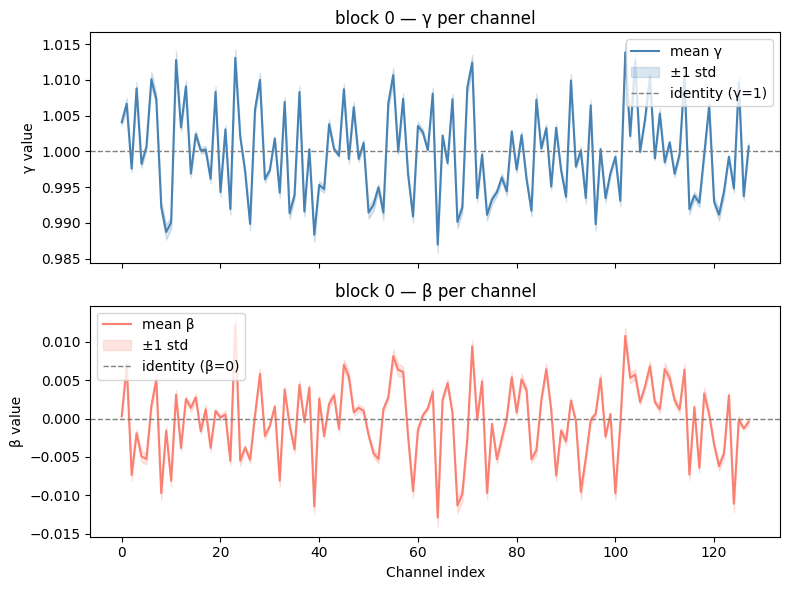

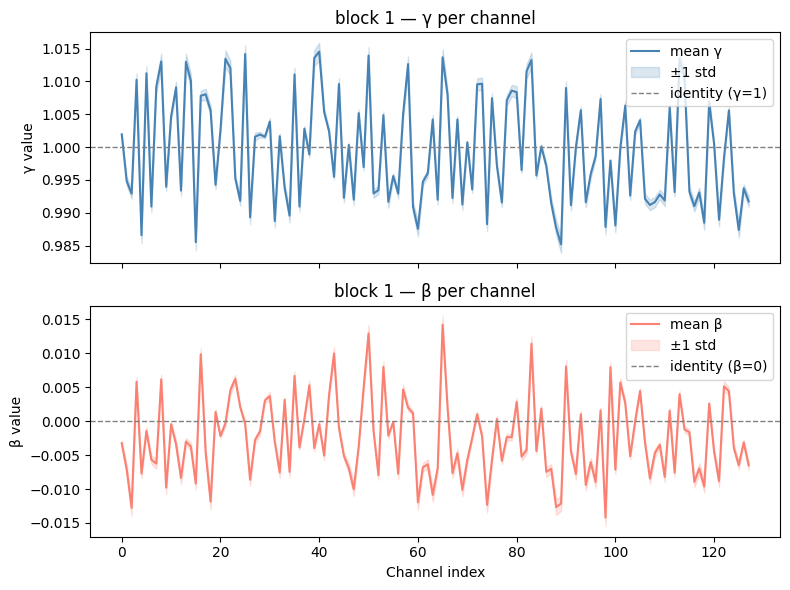

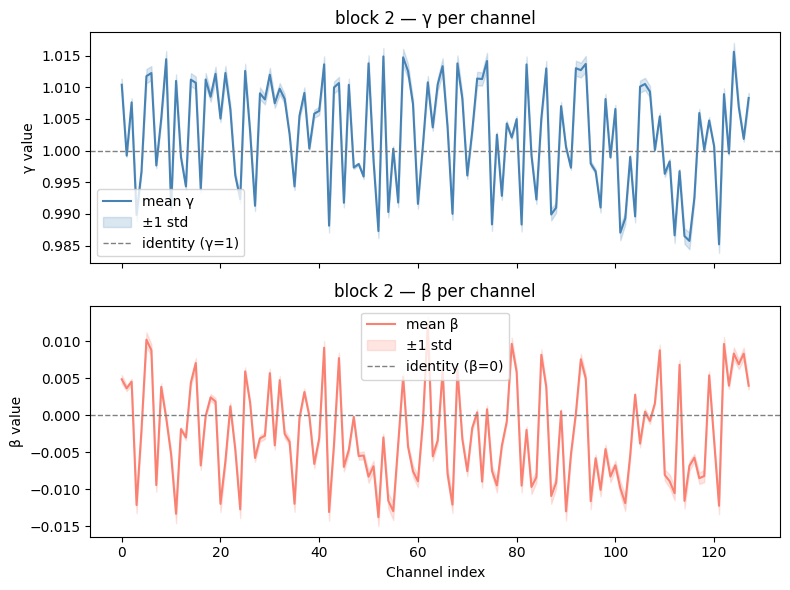

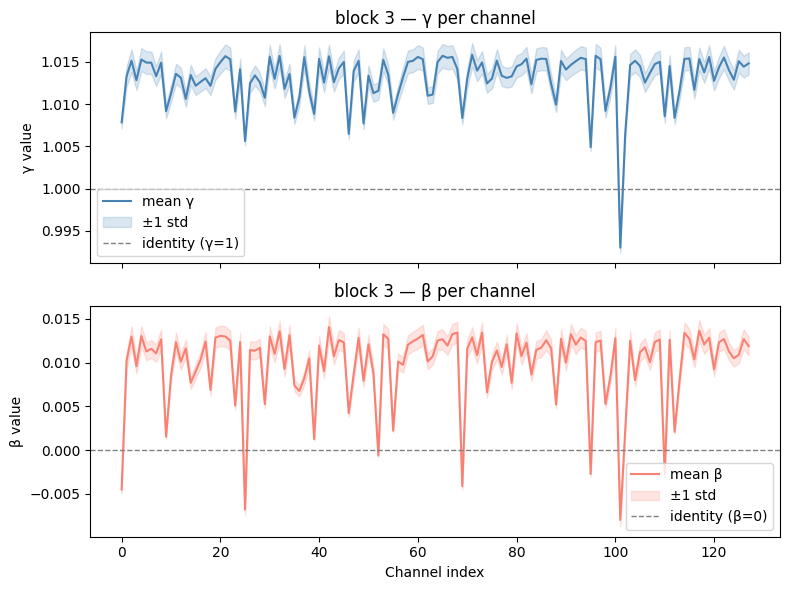

In [8]:
from src.film_analysis import plot_gamma_beta_per_channel

plot_gamma_beta_per_channel(
    gamma   = gamma,
    beta    = beta,
    exp_name = cfg["name"],
    out_dir  = out_dir,
)


[FiLM] Block 0  — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


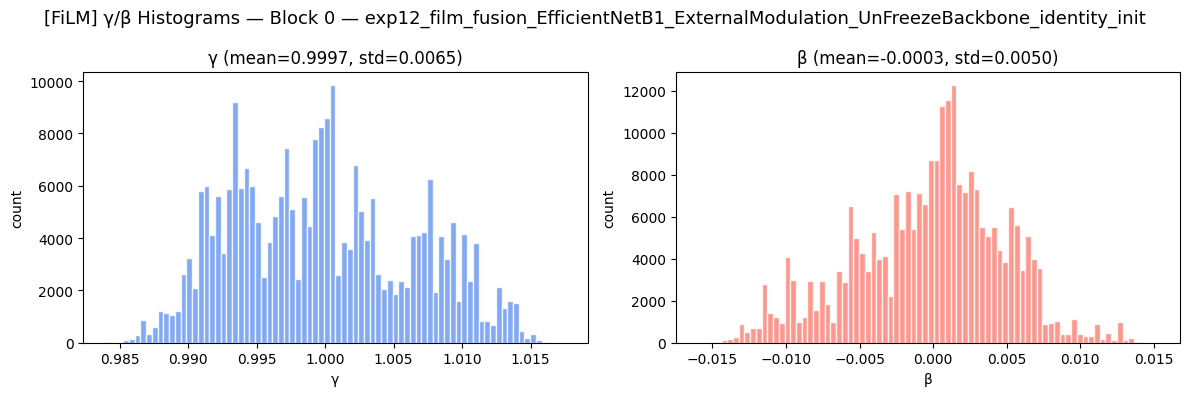

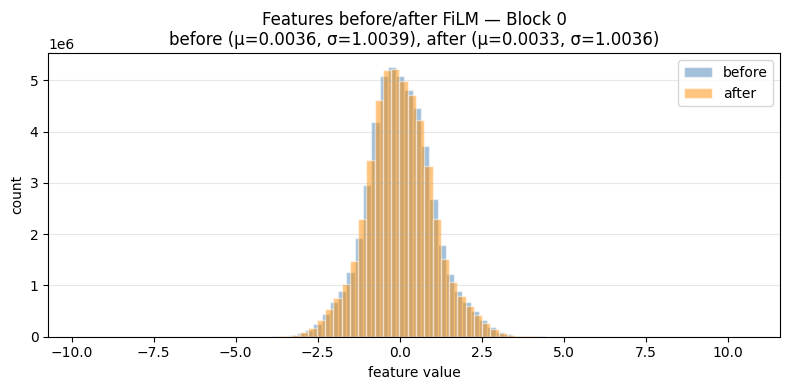

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,0,0,0,0,0,1.197525,1.203290,1.004395,0.000502,0.005765
1,0,0,0,0,1,1.131098,1.136571,1.004395,0.000502,0.005473
2,0,0,0,0,2,0.677034,0.680511,1.004395,0.000502,0.003478
3,0,0,0,0,3,0.492937,0.495606,1.004395,0.000502,0.002668
4,0,0,0,0,4,0.757199,0.761029,1.004395,0.000502,0.003830
...,...,...,...,...,...,...,...,...,...,...
16380,0,0,83,8,0,1.093045,1.077373,0.990981,-0.005815,0.015672
16381,0,0,83,8,1,1.048192,1.032925,0.990981,-0.005815,0.015268
16382,0,0,83,8,2,0.606322,0.595039,0.990981,-0.005815,0.011283
16383,0,0,83,8,3,-0.145724,-0.150224,0.990981,-0.005815,0.004500


[FiLM] Block 0 global stats:
  L2 ||after - before|| = 58.2165


,block_idx,which,min,max,mean,std
0,0,before,-9.704161,10.496120,0.003558,1.003887
1,0,after,-9.588190,10.575779,0.003323,1.003619



[FiLM] Block 1  — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


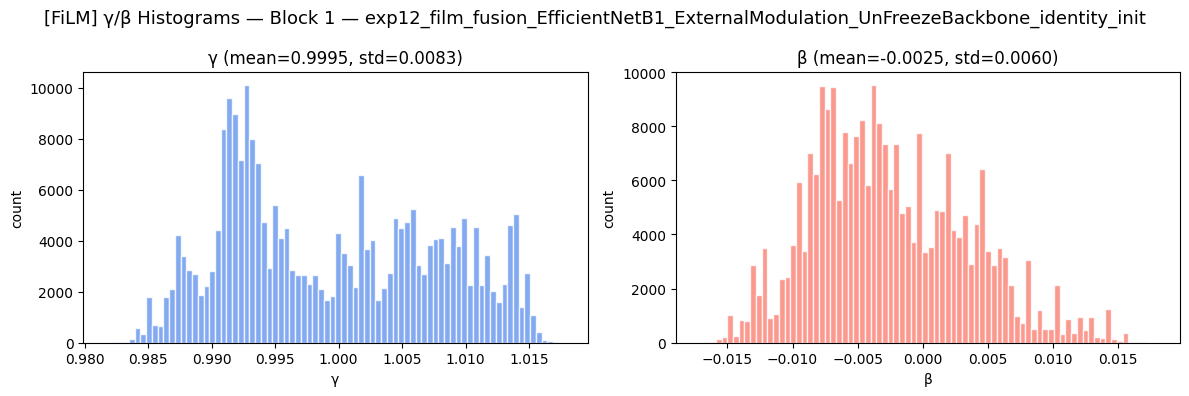

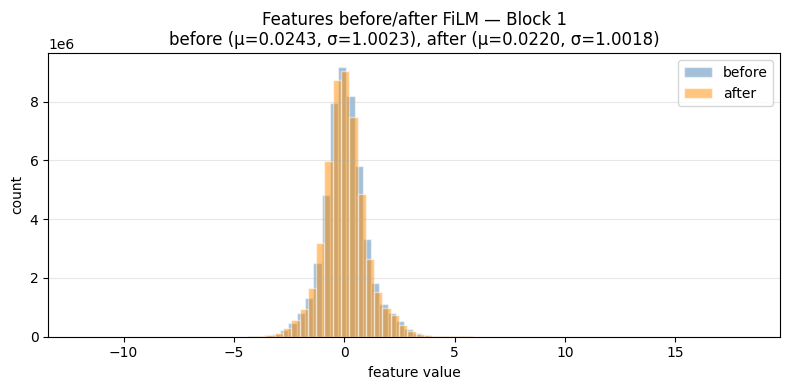

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,1,0,0,0,0,2.973033,2.974992,1.001903,-0.003699,0.001959
1,1,0,0,0,1,0.878050,0.876022,1.001903,-0.003699,0.002028
2,1,0,0,0,2,0.829632,0.827512,1.001903,-0.003699,0.002120
3,1,0,0,0,3,0.327477,0.324401,1.001903,-0.003699,0.003076
4,1,0,0,0,4,0.185044,0.181698,1.001903,-0.003699,0.003347
...,...,...,...,...,...,...,...,...,...,...
16380,1,0,83,8,0,2.160990,2.202712,1.013911,0.011661,0.041722
16381,1,0,83,8,1,-0.958416,-0.960087,1.013911,0.011661,0.001671
16382,1,0,83,8,2,-0.057707,-0.046848,1.013911,0.011661,0.010858
16383,1,0,83,8,3,-0.137956,-0.128213,1.013911,0.011661,0.009742


[FiLM] Block 1 global stats:
  L2 ||after - before|| = 74.3496


,block_idx,which,min,max,mean,std
0,1,before,-11.912793,18.091133,0.024350,1.002317
1,1,after,-11.782998,18.227240,0.021983,1.001825



[FiLM] Block 2  — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


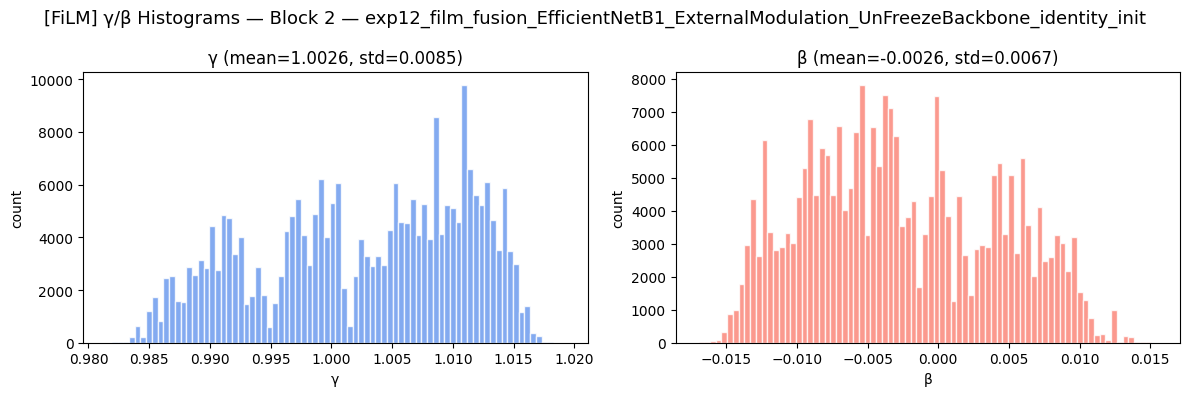

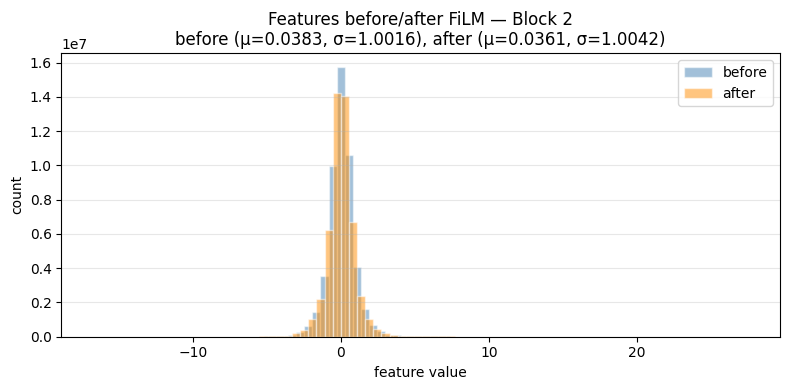

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,2,0,0,0,0,-0.431651,-0.431349,1.010876,0.004997,0.000303
1,2,0,0,0,1,-0.410938,-0.410410,1.010876,0.004997,0.000528
2,2,0,0,0,2,-0.410012,-0.409474,1.010876,0.004997,0.000538
3,2,0,0,0,3,-0.526217,-0.526943,1.010876,0.004997,0.000726
4,2,0,0,0,4,-0.483788,-0.484052,1.010876,0.004997,0.000264
...,...,...,...,...,...,...,...,...,...,...
16380,2,0,83,8,0,1.802486,1.789572,0.998795,-0.010741,0.012913
16381,2,0,83,8,1,-0.152229,-0.162786,0.998795,-0.010741,0.010558
16382,2,0,83,8,2,1.061497,1.049476,0.998795,-0.010741,0.012020
16383,2,0,83,8,3,0.778948,0.767268,0.998795,-0.010741,0.011680


[FiLM] Block 2 global stats:
  L2 ||after - before|| = 81.2276


,block_idx,which,min,max,mean,std
0,2,before,-16.674778,27.020308,0.038295,1.001575
1,2,after,-16.485397,27.461346,0.036073,1.004245



[FiLM] Block 3  — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


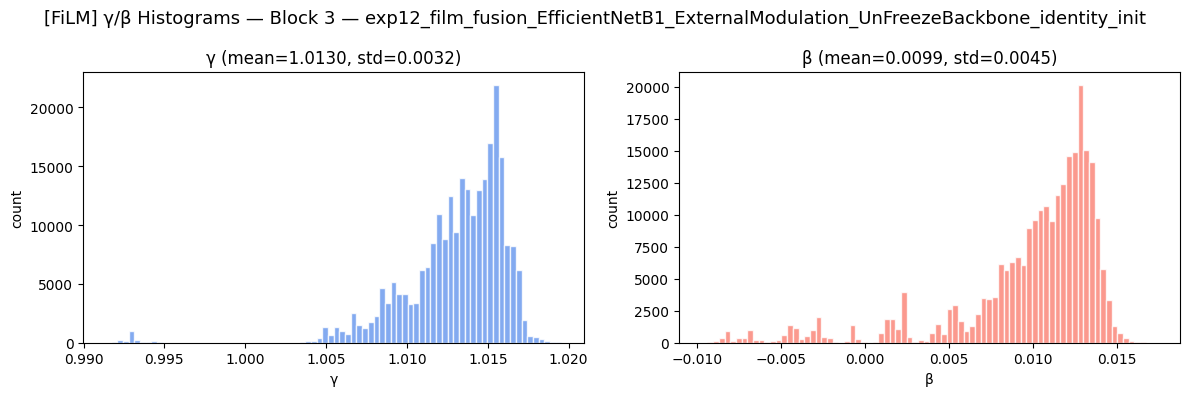

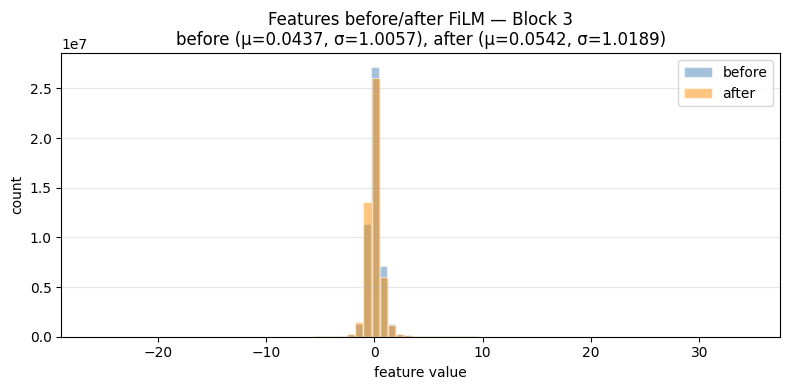

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,3,0,0,0,0,-0.726925,-0.737943,1.008513,-0.004829,0.011018
1,3,0,0,0,1,-0.615909,-0.625982,1.008513,-0.004829,0.010073
2,3,0,0,0,2,-0.567796,-0.577459,1.008513,-0.004829,0.009663
3,3,0,0,0,3,-0.721928,-0.732903,1.008513,-0.004829,0.010975
4,3,0,0,0,4,-0.457994,-0.466722,1.008513,-0.004829,0.008728
...,...,...,...,...,...,...,...,...,...,...
16380,3,0,83,8,0,0.629611,0.647277,1.013203,0.009353,0.017666
16381,3,0,83,8,1,0.057147,0.067255,1.013203,0.009353,0.010108
16382,3,0,83,8,2,-0.047804,-0.039082,1.013203,0.009353,0.008722
16383,3,0,83,8,3,-0.117969,-0.110174,1.013203,0.009353,0.007795


[FiLM] Block 3 global stats:
  L2 ||after - before|| = 125.1932


,block_idx,which,min,max,mean,std
0,3,before,-25.610899,33.88781,0.043712,1.005706
1,3,after,-25.875504,34.42865,0.054232,1.018913


In [9]:
from src.film_analysis import analyze_film_per_block

analyze_film_per_block(
    gamma       = gamma,
    beta        = beta,
    feat_before = feat_before, #feature before FiLM 
    feat_after  = feat_after, # feature after FiLM 
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    n_table_rows = 16385, 
)


[FiLM per-channel] Block 0 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


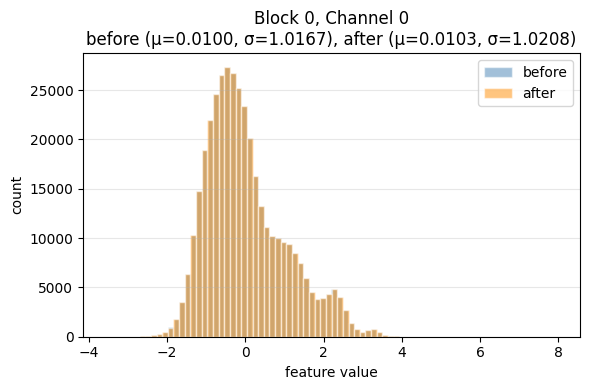

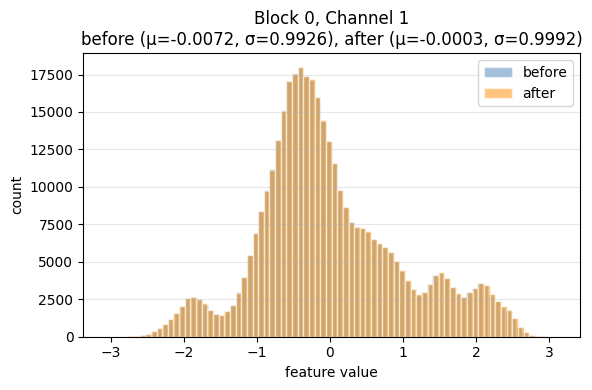

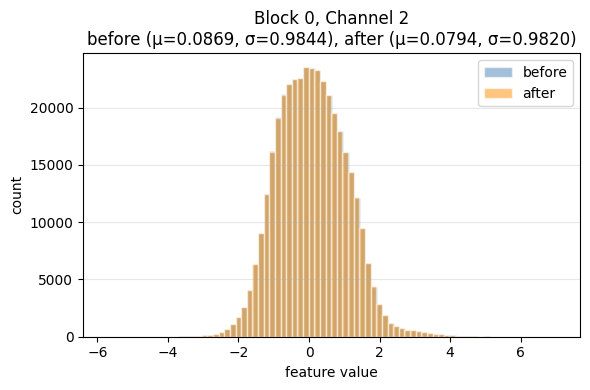

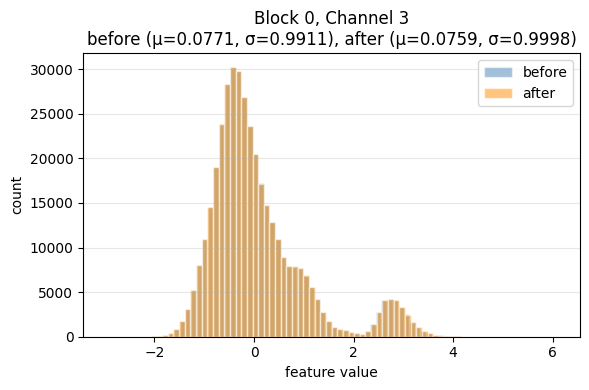


[FiLM per-channel] Block 1 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


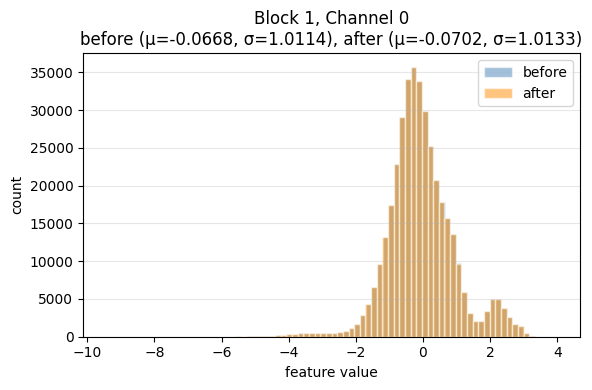

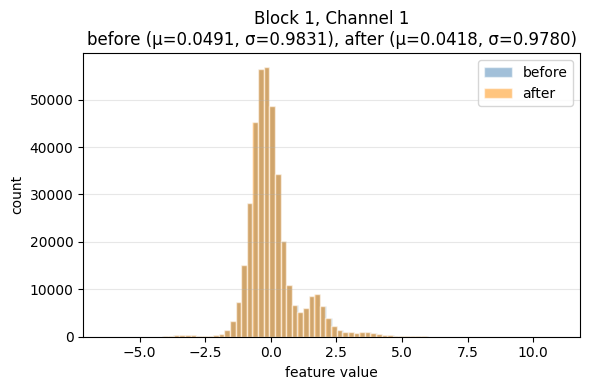

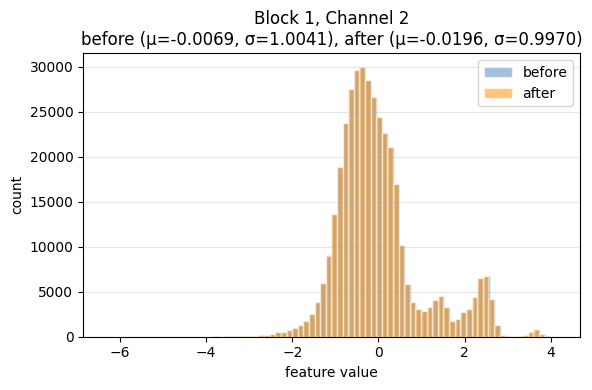

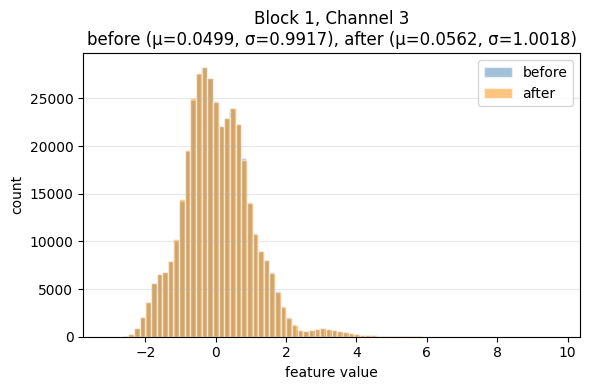


[FiLM per-channel] Block 2 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


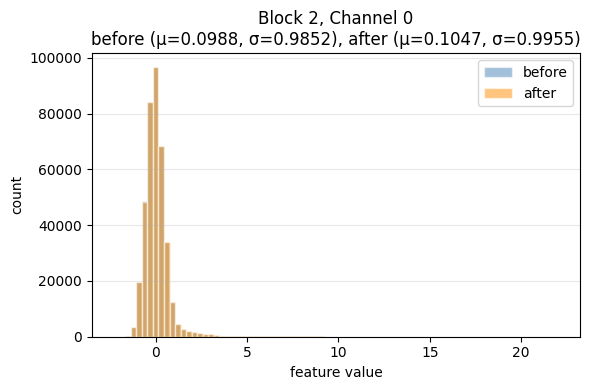

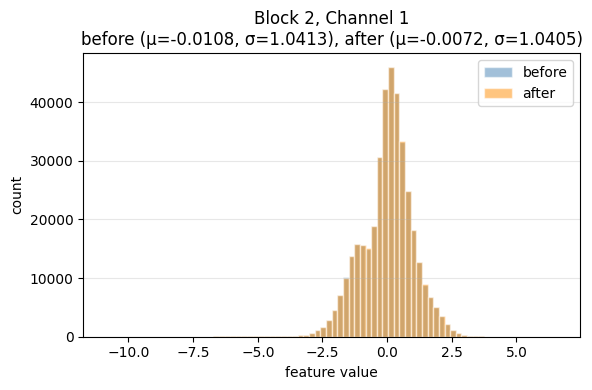

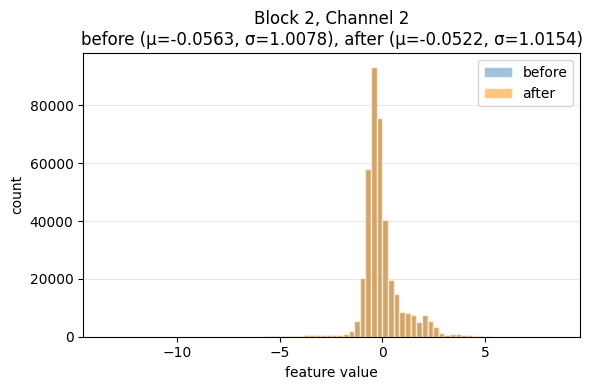

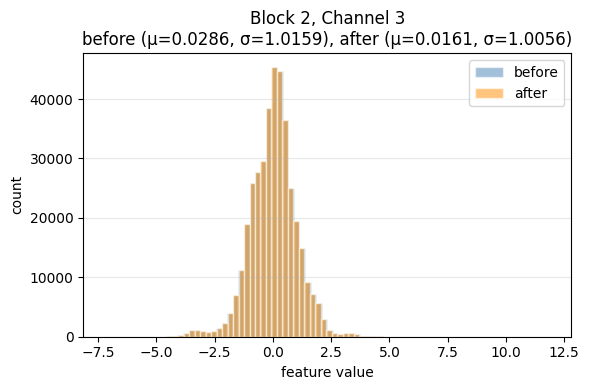


[FiLM per-channel] Block 3 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


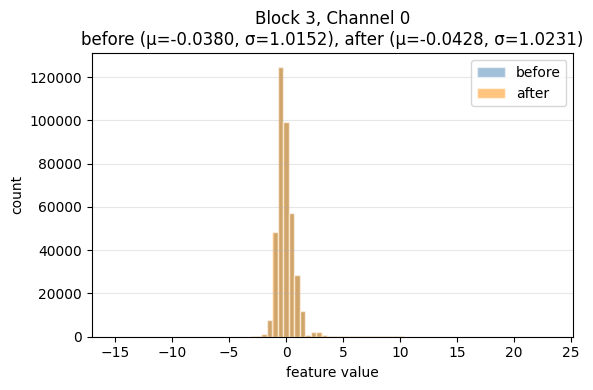

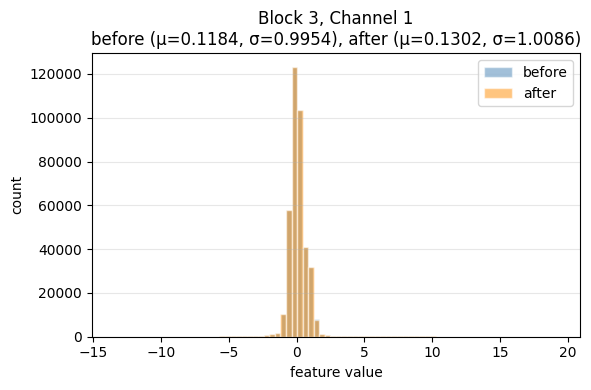

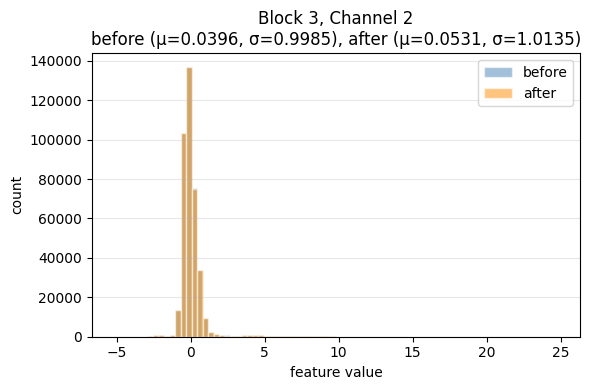

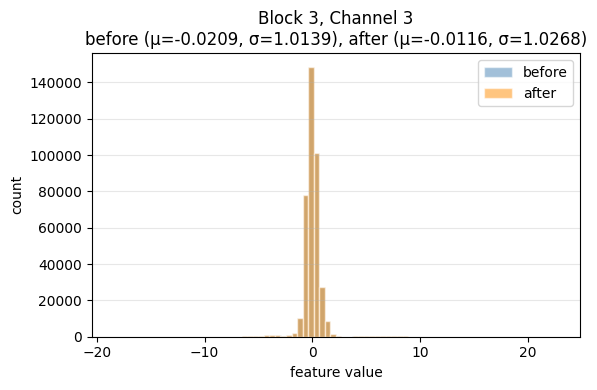

In [10]:
from src.film_analysis import analyze_film_per_channel
analyze_film_per_channel(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_channels = 4,   # e.g. first 4 channels
)


[FiLM per-sample] Block 0 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


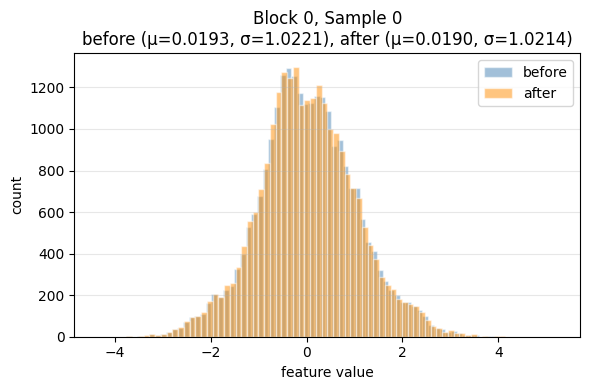

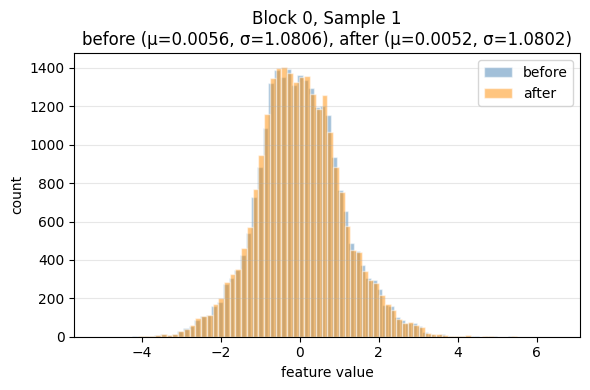

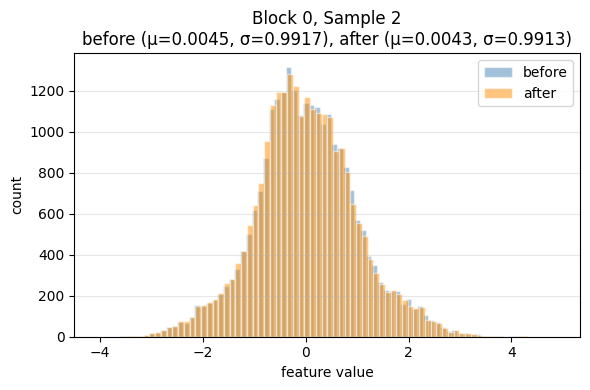

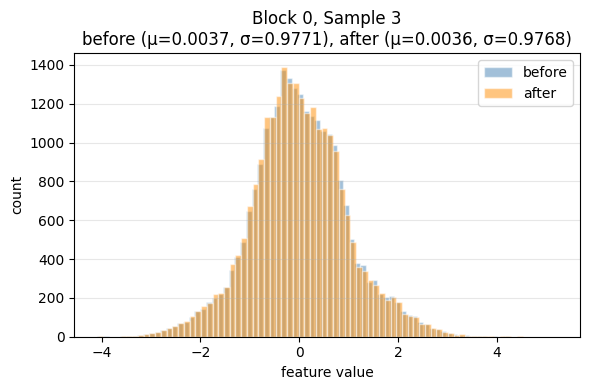


[FiLM per-sample] Block 1 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


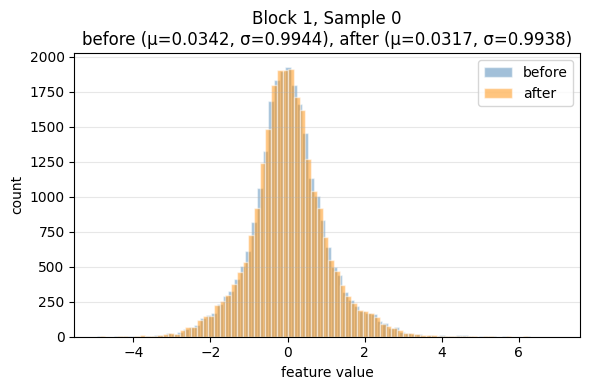

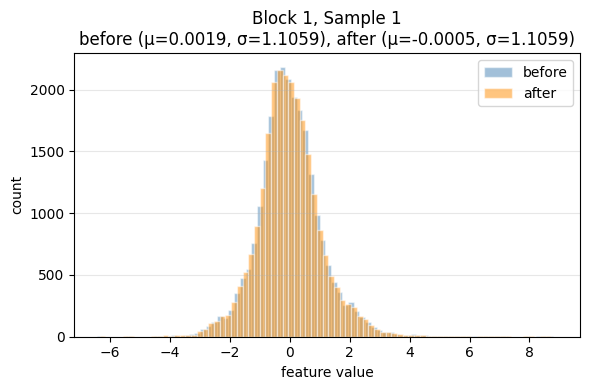

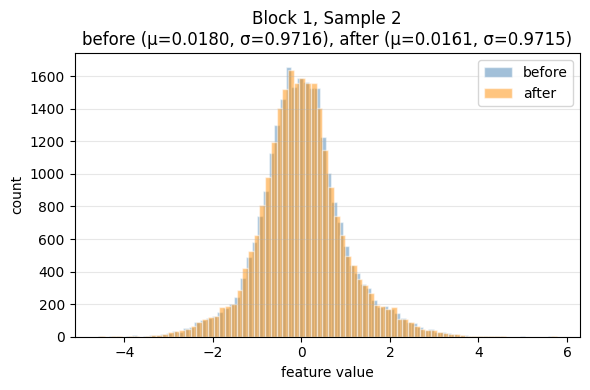

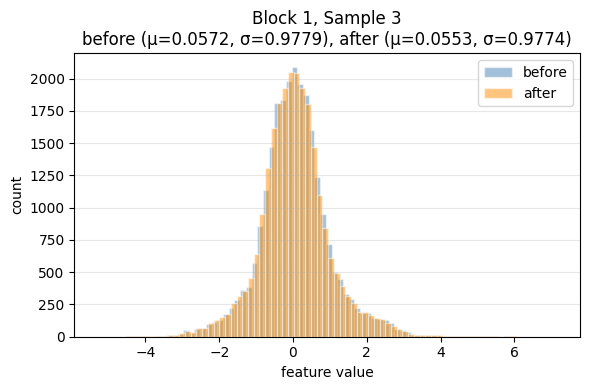


[FiLM per-sample] Block 2 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


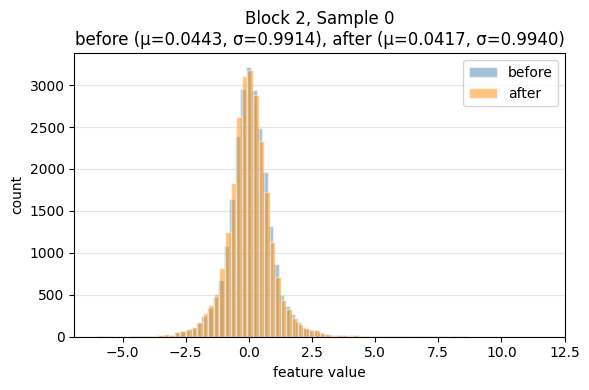

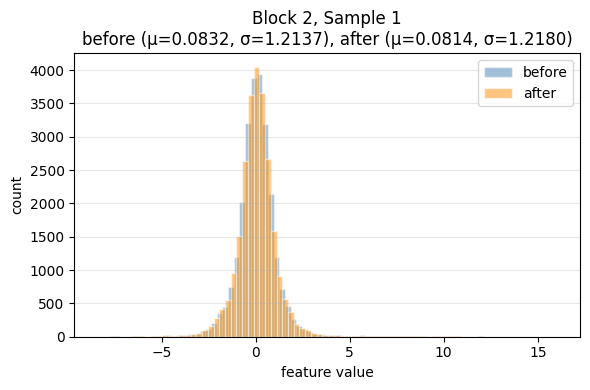

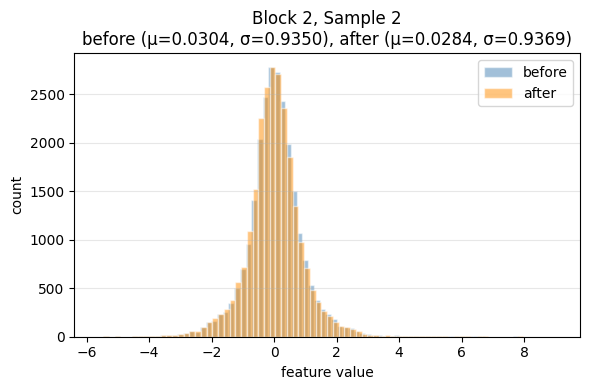

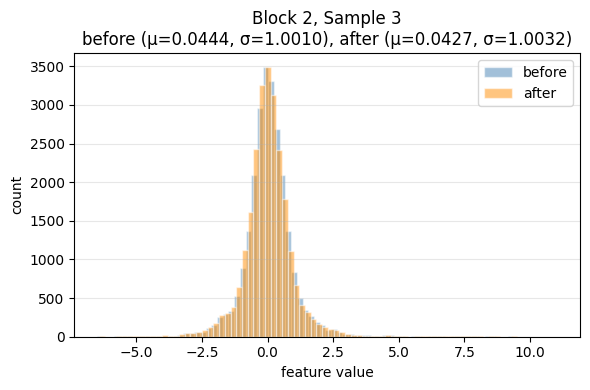


[FiLM per-sample] Block 3 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


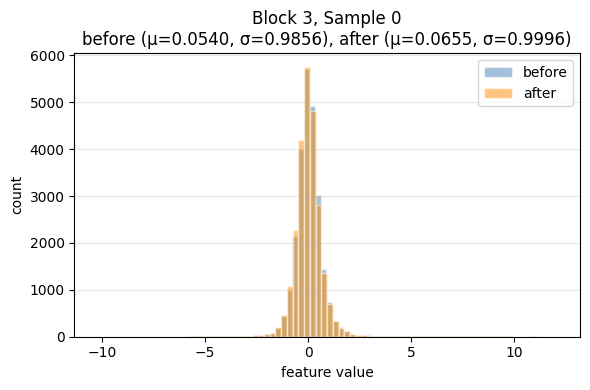

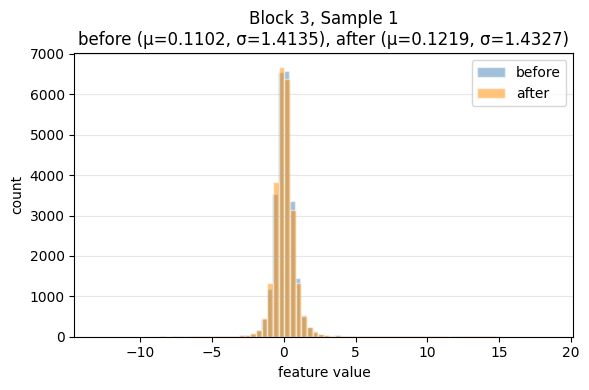

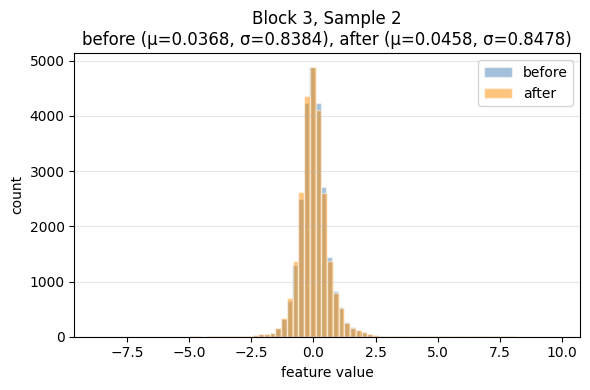

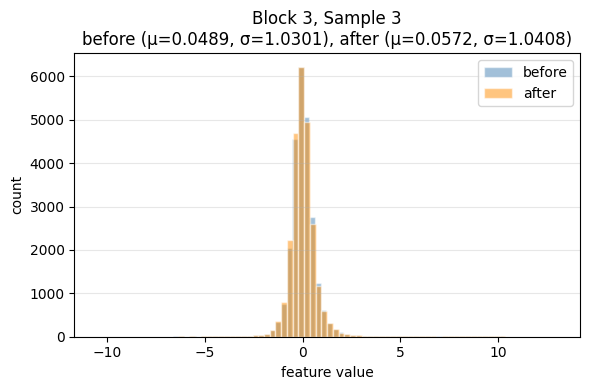

In [11]:
from src.film_analysis import analyze_film_per_sample
analyze_film_per_sample(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_samples = 4,   # e.g. first 4 samples
)